# Figure notebook — *skong_2026*

Every poster figure, rebuilt here from the model-result tables in `output/` and the
processed spectra in `data/processed/`. Each figure has its own **CONFIG** dict at the
top of its cell (colors, titles, fonts, sizes, output filename): edit the dict, re-run
the cell, and the `.svg` in `figures/` is overwritten.

The figures never recompute the models. Steps 4-6 load the metrics the pipeline already
wrote (`irspectra.results.load_csv / load_confusion / load_json`); Steps 1-3 are data
views built straight from the processed spectra. To regenerate the underlying numbers,
run the matching `pipeline/step*.py` first (see the README).

## Shared setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

from irspectra import results, FIGURES_DIR
from irspectra.data import processed, spectra
from irspectra.config import METAL_ORDER
from irspectra.data.spectra import mean_by_length
from irspectra.viz.palette import pretty_metal, METAL_COLORS, METAL_LABELS
from irspectra.viz.panels import annotate_bands, plot_confusion as shared_plot_confusion

plt.rcParams["savefig.transparent"] = True   # transparent background on every saved figure

# processed spectra: one lowest-energy spectrum per molecule (feeds the Step 1-3 data views)
meta, X, sticks = processed.load_processed()
WN = spectra.WN                               # 791 wavenumbers, 50..4000 cm^-1
FIG_DIR = FIGURES_DIR
os.makedirs(FIG_DIR, exist_ok=True)
print(f"{len(meta)} molecules | X {X.shape} | grid {WN.min()}-{WN.max()} cm^-1 ({len(WN)} bins)")
meta.groupby(["length", "metal"]).size().unstack(fill_value=0)

9060 molecules | X (9060, 791) | grid 50-4000 cm^-1 (791 bins)


metal,Co+2,Cu+2,Ni+2,Zn+2,none
length,,,,,
1,20,20,20,20,20
2,399,399,399,399,379
3,1751,1741,1750,1743,0


## Step 1 — Data visualization
Mean simulated IR spectrum at each peptide length (monomer / dimer / trimer), for one metal.
The grey regions mark the standard IR bands, labelled by the bond or group they report on.

wrote C:\IRSpectra\skong_2026\figures\step1_ir_by_length_cu.svg


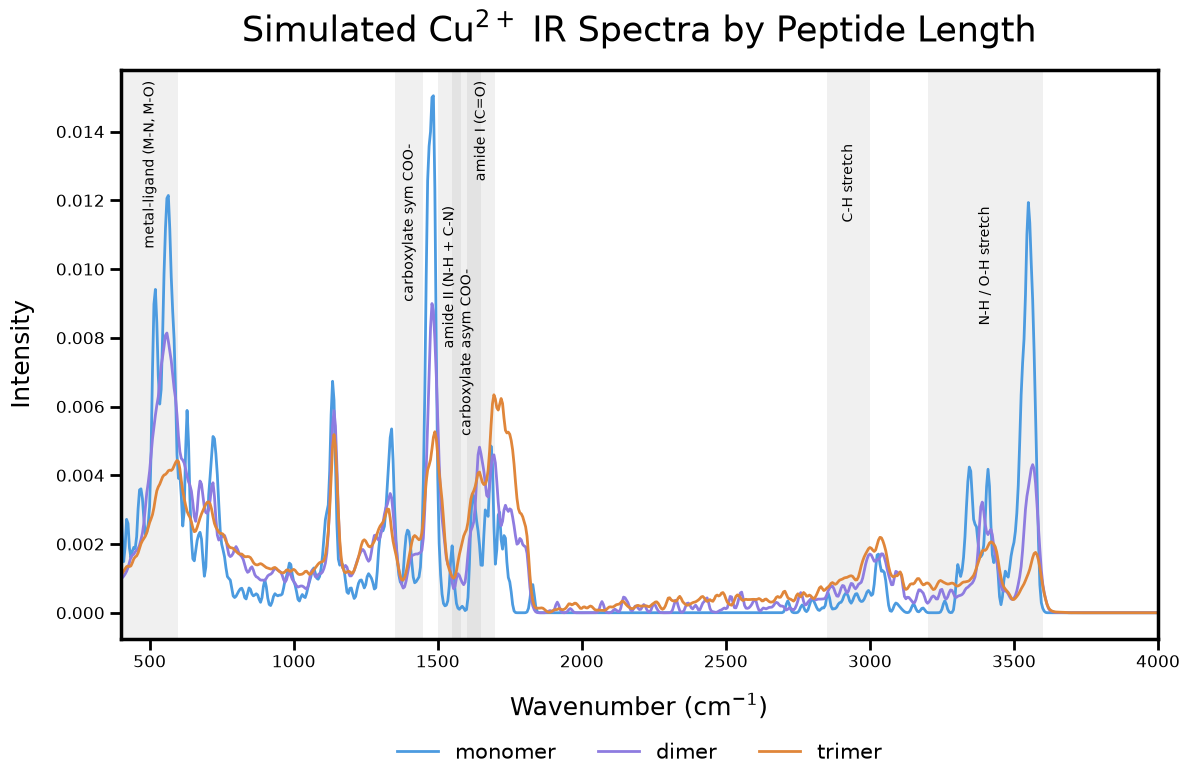

In [2]:
S1 = dict(
    metal_filter    = "Cu+2",     # None = mean over all metals; or "Co+2"/"Ni+2"/"Cu+2"/"Zn+2"
    length_colors   = {1: "#4C9BE0", 2: "#8E7CE0", 3: "#E0863A"},   # monomer / dimer / trimer
    length_labels   = {1: "monomer", 2: "dimer", 3: "trimer"},
    title           = "Simulated Cu$^{2+}$ IR Spectra by Peptide Length",
    xlabel          = r"Wavenumber (cm$^{-1}$)",
    ylabel          = "Intensity",
    xlim            = (400, 4000),
    x_major         = 500,
    show_bands      = True,
    band_fontsize   = 10,
    band_text_color = "black",
    linewidth       = 2,
    title_fontsize  = 25, label_fontsize = 18, legend_fontsize = 15, tick_labelsize = 12,
    spine_width     = 2.5, figsize = (12, 8), legend_ncol = 4,
    outfile         = "step1_ir_by_length_cu.svg",
    dpi             = 600,
)

def plot_step1(cfg):
    spec = mean_by_length(meta, X, cfg["metal_filter"])
    lo, hi = cfg["xlim"]; sel = (WN >= lo) & (WN <= hi)
    fig, ax = plt.subplots(figsize=cfg["figsize"])
    for L in (1, 2, 3):
        ax.plot(WN[sel], spec[L][sel], label=cfg["length_labels"][L],
                linewidth=cfg["linewidth"], color=cfg["length_colors"][L])
    ax.set_xlabel(cfg["xlabel"], fontsize=cfg["label_fontsize"], labelpad=15)
    ax.set_ylabel(cfg["ylabel"], fontsize=cfg["label_fontsize"], labelpad=15)
    ax.set_title(cfg["title"], fontsize=cfg["title_fontsize"], pad=20)
    ax.set_xlim(lo, hi)
    for sp in ax.spines.values(): sp.set_linewidth(cfg["spine_width"])
    ax.xaxis.set_major_locator(MultipleLocator(cfg["x_major"]))
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=cfg["tick_labelsize"])
    if cfg["show_bands"]:
        annotate_bands(ax, fontsize=cfg["band_fontsize"], text_color=cfg.get("band_text_color", "#555"))
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=cfg["legend_ncol"],
              fontsize=cfg["legend_fontsize"], frameon=False)
    fig.tight_layout()
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("wrote", out)
    return fig

plot_step1(S1);

## Step 2 — Featurization
Raw line (stick) spectrum vs the Gaussian-broadened, area-normalized spectrum the model
actually sees, for one molecule (set by `sequence` / `metal`).

wrote C:\IRSpectra\skong_2026\figures\step2_broadening_ME_Ni_C11.svg | molecule: ME Ni+2


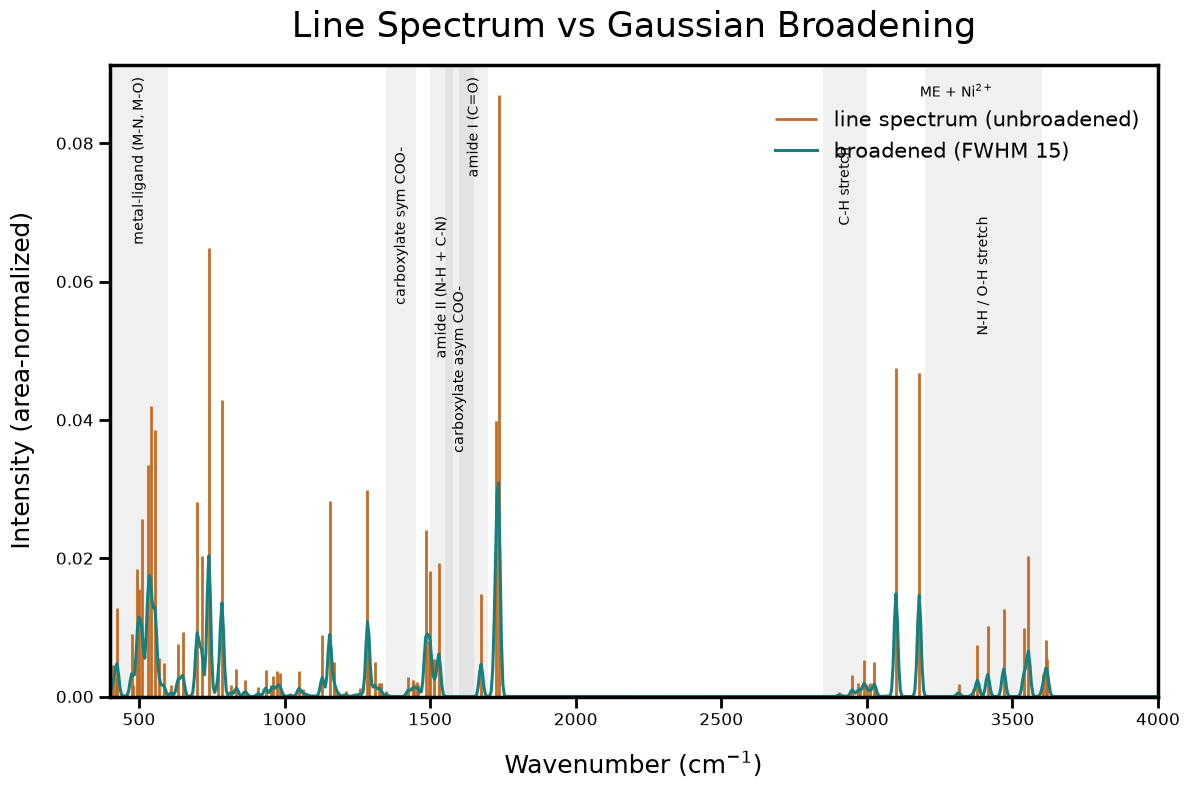

In [3]:
S2 = dict(
    sequence        = "ME",        # peptide sequence; poster molecule = ME + Ni
    metal           = "Ni+2",      # Co+2 / Ni+2 / Cu+2 / Zn+2
    fwhm            = 15.0,         # broadening FWHM (cm^-1)
    stick_color     = "#C1651B",
    broad_color     = "#15807D",
    title           = "Line Spectrum vs Gaussian Broadening",
    xlabel          = r"Wavenumber (cm$^{-1}$)",
    ylabel          = "Intensity (area-normalized)",
    xlim            = (400, 4000), x_major = 500,
    show_bands      = True, band_fontsize = 10, band_text_color = "black",
    linewidth       = 2.2,
    title_fontsize  = 25, label_fontsize = 18, legend_fontsize = 15, tick_labelsize = 12,
    spine_width     = 2.5, figsize = (12, 8),
    outfile         = "step2_broadening_ME_Ni_C11.svg",
    dpi             = 600,
)

def plot_step2(cfg):
    idx = meta.index[(meta.amino_acid == cfg["sequence"]) & (meta.metal == cfg["metal"])]
    if len(idx) == 0:                                   # fall back to first of that metal+length
        alt = meta.index[(meta.metal == cfg["metal"]) & (meta.length == len(cfg["sequence"]))]
        if len(alt) == 0:
            raise ValueError(f"no molecule for metal {cfg['metal']}")
        i = int(alt[0]); print(f"note: {cfg['sequence']}/{cfg['metal']} absent -> using {meta.loc[i,'amino_acid']}")
    else:
        i = int(idx[0])
    s = sticks[i].astype(float)
    raw = s / (s.sum() or 1.0)
    broad = spectra.broaden_normalize(s[None, :], fwhm=cfg["fwhm"])[0]
    lo, hi = cfg["xlim"]; sel = (WN >= lo) & (WN <= hi)
    fig, ax = plt.subplots(figsize=cfg["figsize"])
    ax.vlines(WN[sel], 0, raw[sel], color=cfg["stick_color"], linewidth=2.0, alpha=0.95,
              label="line spectrum (unbroadened)")
    ax.plot(WN[sel], broad[sel], color=cfg["broad_color"], linewidth=cfg["linewidth"],
            label=f"broadened (FWHM {cfg['fwhm']:g})")
    ax.set_xlabel(cfg["xlabel"], fontsize=cfg["label_fontsize"], labelpad=15)
    ax.set_ylabel(cfg["ylabel"], fontsize=cfg["label_fontsize"], labelpad=15)
    ax.set_title(cfg["title"], fontsize=cfg["title_fontsize"], pad=20)
    ax.set_xlim(lo, hi); ax.set_ylim(bottom=0)
    for sp in ax.spines.values(): sp.set_linewidth(cfg["spine_width"])
    ax.xaxis.set_major_locator(MultipleLocator(cfg["x_major"]))
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=cfg["tick_labelsize"])
    if cfg["show_bands"]:
        annotate_bands(ax, fontsize=cfg["band_fontsize"], text_color=cfg.get("band_text_color", "#555"))
    ax.legend(loc="upper right", ncol=1, fontsize=cfg["legend_fontsize"], frameon=False,
              title=f"{meta.loc[i,'amino_acid']} + {pretty_metal(cfg['metal'])}")
    fig.tight_layout()
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("wrote", out, "| molecule:", meta.loc[i, "amino_acid"], cfg["metal"])
    return fig

plot_step2(S2);

## Step 3 — Data analysis (PCA)
PCA of the monomer + dimer metal complexes (all conformers). The metals overlap in the
leading components, which motivates the nonlinear RandomForest. Reads the saved PCA coords
(`output/step3/`) so it does not recompute the decomposition.

wrote C:\IRSpectra\skong_2026\figures\step3_pca_metals_means.svg | 24685 conformers, 1676 molecule means


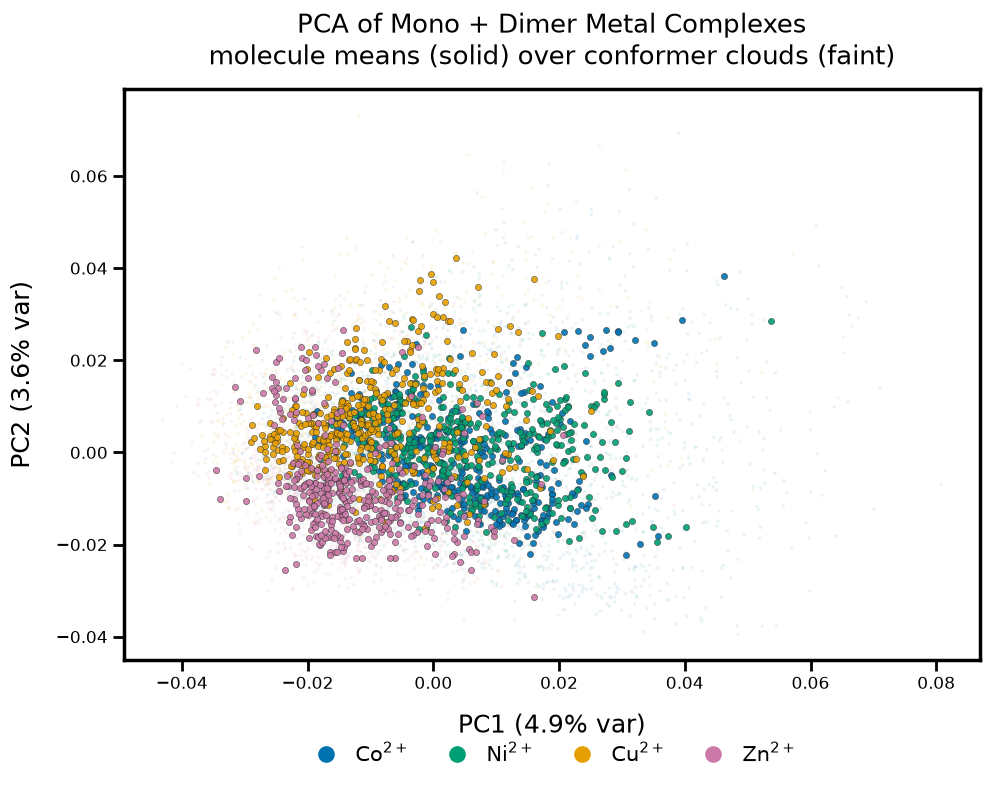

In [4]:
S3M = dict(
    coords_csv   = "pca_coords.csv", evr_json = "evr.json",
    metal_colors = METAL_COLORS, metal_labels = METAL_LABELS, metal_order = METAL_ORDER,
    cloud_n      = 1200, cloud_alpha = 0.09, mean_size = 20,
    title        = "PCA of Mono + Dimer Metal Complexes\nmolecule means (solid) over conformer clouds (faint)",
    title_fontsize = 19, label_fontsize = 18, legend_fontsize = 15, tick_labelsize = 12,
    spine_width  = 2.5, figsize = (10, 8),
    outfile      = "step3_pca_metals_means.svg", dpi = 600,
)

def plot_step3_means(cfg):
    d = results.load_csv("step3", cfg["coords_csv"])
    evr = results.load_json("step3", cfg["evr_json"])["evr_percent"]
    means = d.groupby("molecule").agg(PC1=("PC1", "mean"), PC2=("PC2", "mean"),
                                      metal=("metal", "first")).reset_index()
    rng = np.random.RandomState(0)
    fig, ax = plt.subplots(figsize=cfg["figsize"])
    for m in cfg["metal_order"]:                            # faint conformer clouds (subsampled)
        idx = np.where(d.metal.values == m)[0]
        sub = rng.choice(idx, size=min(cfg["cloud_n"], len(idx)), replace=False)
        ax.scatter(d.PC1.values[sub], d.PC2.values[sub], s=6, color=cfg["metal_colors"][m],
                   alpha=cfg["cloud_alpha"], edgecolors="none", zorder=2)
    for m in cfg["metal_order"]:                            # molecule means, bold on top
        sel = means.metal == m
        ax.scatter(means.loc[sel, "PC1"], means.loc[sel, "PC2"], s=cfg["mean_size"],
                   color=cfg["metal_colors"][m], alpha=0.9, edgecolors="#2b2b2b", linewidths=0.35, zorder=3)
    ax.set_xlabel(f"PC1 ({evr[0]:.1f}% var)", fontsize=cfg["label_fontsize"], labelpad=15)
    ax.set_ylabel(f"PC2 ({evr[1]:.1f}% var)", fontsize=cfg["label_fontsize"], labelpad=15)
    ax.set_title(cfg["title"], fontsize=cfg["title_fontsize"], pad=18)
    for sp in ax.spines.values(): sp.set_linewidth(cfg["spine_width"])
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=cfg["tick_labelsize"])
    h = [Line2D([0], [0], marker="o", linestyle="", markersize=12, markeredgecolor="none",
                markerfacecolor=cfg["metal_colors"][m], label=cfg["metal_labels"][m]) for m in cfg["metal_order"]]
    ax.legend(handles=h, loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=4, frameon=False,
              fontsize=cfg["legend_fontsize"], columnspacing=1.2, handletextpad=0.4)
    fig.tight_layout()
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("wrote", out, "|", len(d), "conformers,", len(means), "molecule means")
    return fig

plot_step3_means(S3M);

wrote C:\IRSpectra\skong_2026\figures\step3_pca_loadings.svg | PC1 4.9%  PC2 3.6%


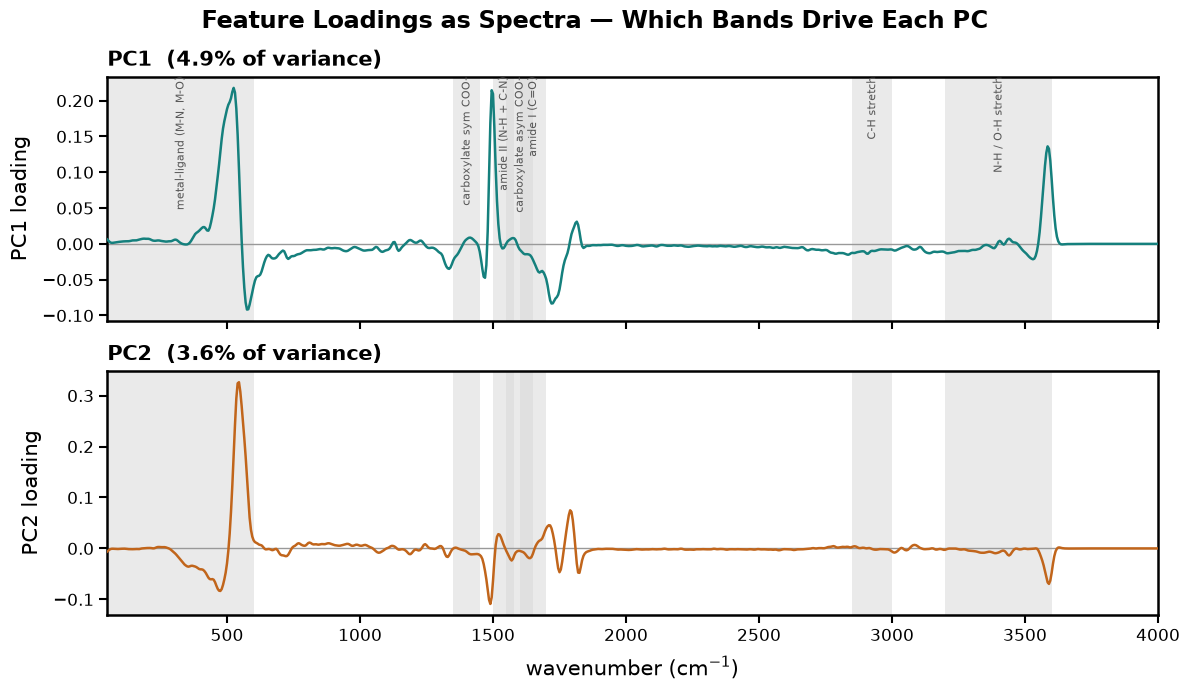

In [5]:
S3L = dict(
    loadings_csv = "pca_loadings.csv", evr_json = "evr.json",
    colors       = ["#15807D", "#C1651B"],   # PC1 green, PC2 orange
    title        = "Feature Loadings as Spectra — Which Bands Drive Each PC",
    figsize      = (12, 7), outfile = "step3_pca_loadings.svg", dpi = 600,
)

def plot_step3_loadings(cfg):
    L = results.load_csv("step3", cfg["loadings_csv"])          # index = wavenumber, cols PC1_loading/PC2_loading
    wn = L["wavenumber"].to_numpy() if "wavenumber" in L.columns else L.iloc[:, 0].to_numpy()
    comp = [L["PC1_loading"].to_numpy(), L["PC2_loading"].to_numpy()]
    evr = results.load_json("step3", cfg["evr_json"])["evr_percent"]
    fig, axes = plt.subplots(2, 1, figsize=cfg["figsize"], sharex=True)
    for k, ax in enumerate(axes):
        for lo, hi, _ in spectra.BANDS:
            ax.axvspan(lo, hi, color="0.85", alpha=0.55, lw=0, zorder=0)
        ax.axhline(0, color="0.6", lw=1, zorder=1)
        ax.plot(wn, comp[k], color=cfg["colors"][k], lw=1.8, zorder=3)
        ax.set_ylabel(f"PC{k+1} loading", fontsize=15, labelpad=8)
        ax.set_title(f"PC{k+1}  ({evr[k]:.1f}% of variance)", fontsize=15, loc="left", fontweight="bold", pad=8)
        for sp in ax.spines.values(): sp.set_linewidth(1.8)
        ax.tick_params(axis="both", which="major", length=6, width=1.5, labelsize=12)
    y1 = axes[0].get_ylim()[1]
    for lo, hi, label in spectra.BANDS:
        axes[0].text((lo + hi) / 2, y1, label, rotation=90, va="top", ha="center", fontsize=8, color="0.35")
    axes[0].set_xlim(wn.min(), wn.max())
    axes[1].set_xlabel(r"wavenumber (cm$^{-1}$)", fontsize=15, labelpad=8)
    fig.suptitle(cfg["title"], fontsize=17, fontweight="bold")
    fig.tight_layout()
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("wrote", out, f"| PC1 {evr[0]:.1f}%  PC2 {evr[1]:.1f}%")
    return fig

plot_step3_loadings(S3L);

## Step 4 — Model training
Per-conformer RandomForest, 10-seed Monte-Carlo cross-validation on the monomer + dimer
complexes. The CV curve reports macro-F1 per seed; the confusion matrix shows per-metal
recall (Co and Ni are the confusable pair).

wrote C:\IRSpectra\skong_2026\figures\step4_cv_macrof1.svg | mean macro-F1 0.812 ± 0.006


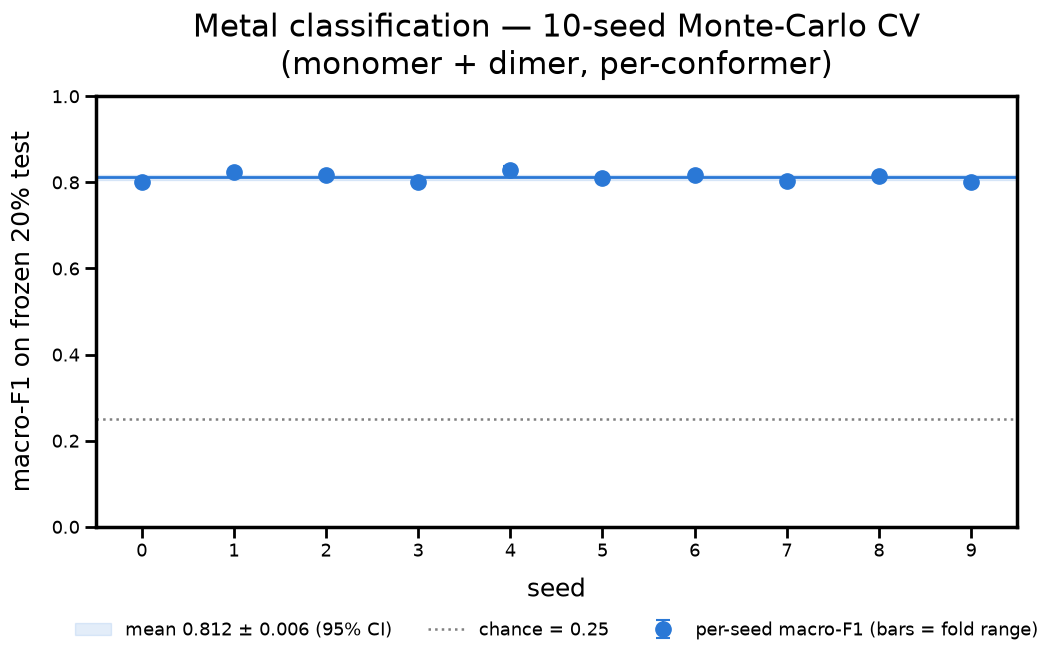

In [6]:
S4CV = dict(
    csv = "cv_results_macrof1.csv", color = "#2A78D6", chance = 0.25,
    ylabel = "macro-F1 on frozen 20% test",
    title  = "Metal classification — 10-seed Monte-Carlo CV\n(monomer + dimer, per-conformer)",
    figsize = (11, 7), outfile = "step4_cv_macrof1.svg", dpi = 600,
)

def plot_cv_macrof1(cfg):
    df = results.load_csv("step4", cfg["csv"]).sort_values("seed")
    foldcols = [c for c in df.columns if c.startswith("fold")]
    m = df["macro_f1"].to_numpy(); ci = 1.96 * m.std(ddof=1) / np.sqrt(len(m))
    lo = df["macro_f1"] - df[foldcols].min(axis=1); hi = df[foldcols].max(axis=1) - df["macro_f1"]
    fig, ax = plt.subplots(figsize=cfg["figsize"])
    ax.errorbar(df["seed"], df["macro_f1"], yerr=[lo, hi], fmt="o", ms=11, color=cfg["color"],
                capsize=5, elinewidth=1.5, capthick=1.5, zorder=3,
                label="per-seed macro-F1 (bars = fold range)")
    ax.axhline(m.mean(), ls="-", color=cfg["color"], lw=2, zorder=2)
    ax.fill_between([-0.5, len(m) - 0.5], m.mean() - ci, m.mean() + ci, color=cfg["color"], alpha=0.13,
                    zorder=1, label=f"mean {m.mean():.3f} ± {ci:.3f} (95% CI)")
    ax.axhline(cfg["chance"], ls=":", color="0.5", lw=1.8, zorder=2, label=f"chance = {cfg['chance']:.2f}")
    ax.set_xticks(range(len(m))); ax.set_xlim(-0.5, len(m) - 0.5); ax.set_ylim(0, 1)
    ax.set_xlabel("seed", fontsize=18, labelpad=12)
    ax.set_ylabel(cfg["ylabel"], fontsize=18, labelpad=12)
    ax.set_title(cfg["title"], fontsize=22, pad=16)
    for sp in ax.spines.values(): sp.set_linewidth(2.5)
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=13)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=3, frameon=False, fontsize=13)
    fig.tight_layout()
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("wrote", out, f"| mean macro-F1 {m.mean():.3f} ± {ci:.3f}")
    return fig

plot_cv_macrof1(S4CV);

In [ ]:
# shared confusion-matrix plotter -- the RENDERER now lives in irspectra.viz.panels so the
# step scripts and this notebook draw identical panels; this cell only loads + saves.
CONF_BASE = dict(
    metals = METAL_ORDER, metal_labels = METAL_LABELS, metal_colors = METAL_COLORS,
    title_fontsize = 20, label_fontsize = 17, tick_labelsize = 16, cell_fontsize = 16,
    figsize = (7.0, 6.0), dpi = 600,
)

def plot_confusion(cfg):
    dfc = results.load_confusion(cfg["subdir"], cfg["csv"])       # already mean row-normalized recall
    fig, ax = shared_plot_confusion(
        dfc, cfg["title"], cmap=cfg["cmap"], metals=cfg["metals"], figsize=cfg["figsize"],
        title_fontsize=cfg["title_fontsize"], label_fontsize=cfg["label_fontsize"],
        tick_labelsize=cfg["tick_labelsize"], cell_fontsize=cfg["cell_fontsize"])
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    cm = dfc.loc[cfg["metals"], cfg["metals"]].to_numpy(float)
    print("wrote", out, "| recall:", {m: round(cm[i, i], 3) for i, m in enumerate(cfg["metals"])})
    return fig

S4C = {**CONF_BASE, "subdir": "step4", "csv": "confusion_perconformer_cap10.csv", "cmap": "Blues",
       "title": "Per-conformer model \u2014 per-metal confusion\n(out-of-fold, mean of 10 seeds)",
       "outfile": "step4_confusion_perconformer_cap10.svg"}
plot_confusion(S4C);

## Step 5 — Zero-shot test on trimers
The mono+di model applied to trimers it never saw. Overall macro-F1 drops from the
in-distribution ceiling to the trimer sets; the two confusion matrices show where.

wrote C:\IRSpectra\skong_2026\figures\step5_zeroshot_cap10.svg | macro-F1: {'monodi': np.float64(0.814), 'trimer_whole': np.float64(0.633), 'trimer_part': np.float64(0.632)}


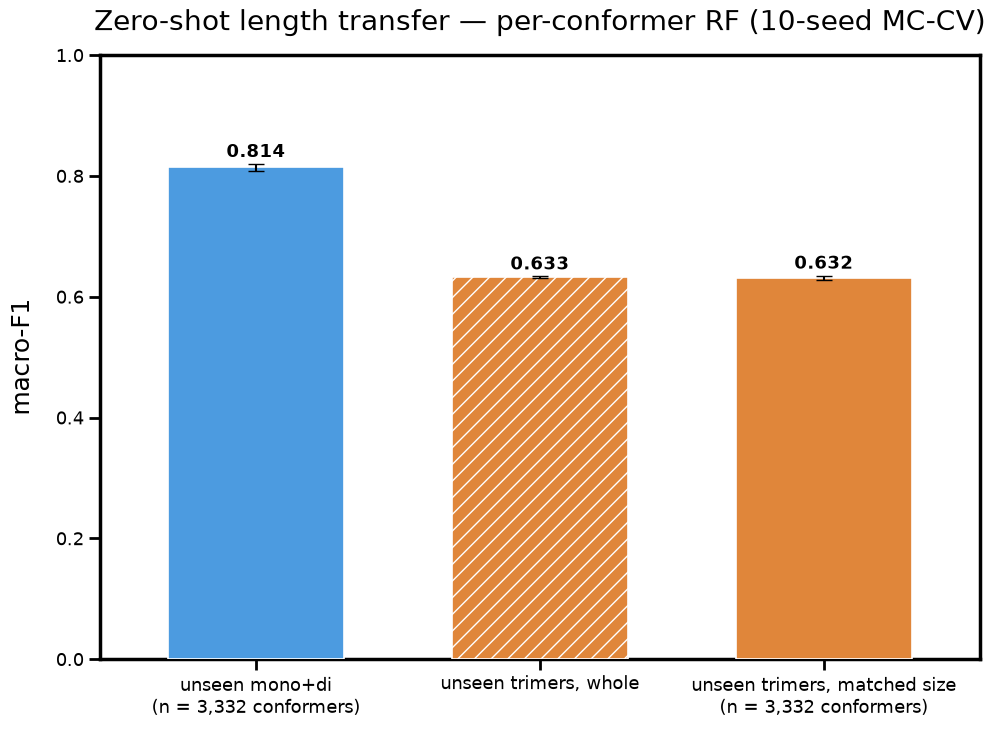

In [8]:
S5 = dict(
    csv    = "zeroshot_results_cap10.csv",
    order  = ["monodi", "trimer_whole", "trimer_part"],
    labels = {"monodi": "unseen mono+di", "trimer_whole": "unseen trimers, whole",
              "trimer_part": "unseen trimers, matched size"},
    colors = {"monodi": "#4C9BE0", "trimer_whole": "#E0863A", "trimer_part": "#E0863A"},
    hatches = {"trimer_whole": "//"},
    n_whole = None,     # set an int to print the whole-trimer conformer count on the tick label
    title  = "Zero-shot length transfer — per-conformer RF (10-seed MC-CV)",
    ylabel = "macro-F1", ymin = 0.0, ymax = 1.0, bar_width = 0.62,
    title_fontsize = 20, label_fontsize = 18, tick_labelsize = 13,
    spine_width = 2.5, figsize = (10, 7.4),
    outfile = "step5_zeroshot_cap10.svg", dpi = 600,
)

def plot_zeroshot(cfg):
    df = results.load_csv("step5", cfg["csv"]); n = len(df); order = cfg["order"]
    means = [df[c].mean() for c in order]
    cis   = [1.96 * df[c].std(ddof=1) / np.sqrt(n) for c in order]
    x = np.arange(len(order))
    n_hold = int(round(df["n_test_conformers"].mean()))
    counts = {"monodi": n_hold, "trimer_part": n_hold, "trimer_whole": cfg.get("n_whole")}
    def _lab(c):
        k = counts.get(c)
        return cfg["labels"][c] + (f"\n(n = {k:,} conformers)" if k else "")
    fig, ax = plt.subplots(figsize=cfg["figsize"])
    bars = ax.bar(x, means, yerr=cis, width=cfg["bar_width"], capsize=6, edgecolor="white",
                  linewidth=1.2, color=[cfg["colors"][c] for c in order], zorder=3)
    for b, c in zip(bars, order):
        if cfg.get("hatches", {}).get(c): b.set_hatch(cfg["hatches"][c])
    for xi, mv, ci in zip(x, means, cis):
        ax.annotate(f"{mv:.3f}", (xi, mv + ci), xytext=(0, 5), textcoords="offset points",
                    ha="center", fontsize=13, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels([_lab(c) for c in order], fontsize=cfg["tick_labelsize"])
    ax.set_xlim(-0.55, len(order) - 0.45)
    ax.set_ylabel(cfg["ylabel"], fontsize=cfg["label_fontsize"], labelpad=15)
    ax.set_title(cfg["title"], fontsize=cfg["title_fontsize"], pad=18)
    ax.set_ylim(cfg["ymin"], cfg["ymax"])
    for sp in ax.spines.values(): sp.set_linewidth(cfg["spine_width"])
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=cfg["tick_labelsize"])
    fig.tight_layout()
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("wrote", out, "| macro-F1:", {c: round(m, 3) for c, m in zip(order, means)})
    return fig

plot_zeroshot(S5);

wrote C:\IRSpectra\skong_2026\figures\step5_confusion_trimer_part_cap10.svg | recall: {'Co+2': np.float64(0.609), 'Ni+2': np.float64(0.494), 'Cu+2': np.float64(0.683), 'Zn+2': np.float64(0.755)}


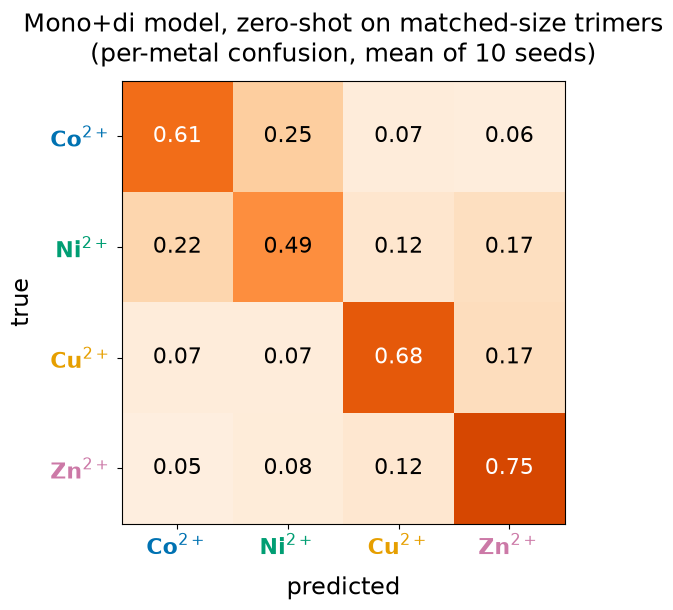

In [9]:
S5CP = {**CONF_BASE, "subdir": "step5", "csv": "confusion_trimer_part_cap10.csv", "cmap": "Oranges",
        "title": "Mono+di model, zero-shot on matched-size trimers\n(per-metal confusion, mean of 10 seeds)",
        "title_fontsize": 18, "figsize": (7.0, 6.2),
        "outfile": "step5_confusion_trimer_part_cap10.svg"}
plot_confusion(S5CP);

wrote C:\IRSpectra\skong_2026\figures\step5_confusion_trimer_whole_cap10.svg | recall: {'Co+2': np.float64(0.612), 'Ni+2': np.float64(0.488), 'Cu+2': np.float64(0.687), 'Zn+2': np.float64(0.758)}


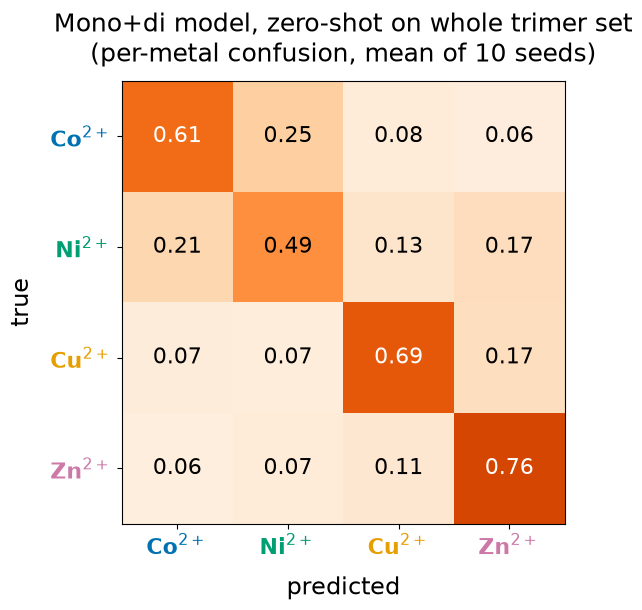

In [10]:
S5CW = {**CONF_BASE, "subdir": "step5", "csv": "confusion_trimer_whole_cap10.csv", "cmap": "Oranges",
        "title": "Mono+di model, zero-shot on whole trimer set\n(per-metal confusion, mean of 10 seeds)",
        "title_fontsize": 18, "figsize": (7.0, 6.2),
        "outfile": "step5_confusion_trimer_whole_cap10.svg"}
plot_confusion(S5CW);

## Step 6 — Adding trimers to the training set
As distinct trimers enter training, macro-F1 on held-out trimers climbs. The frontier is
the zoomed first stretch (add-unique vs add-duplicate); the substitution panel is the 2x2
of anchor length x added length, against the per-conformer trimer ceiling.

wrote C:\IRSpectra\skong_2026\figures\step6_frontier_figC_zoom_cap10.svg


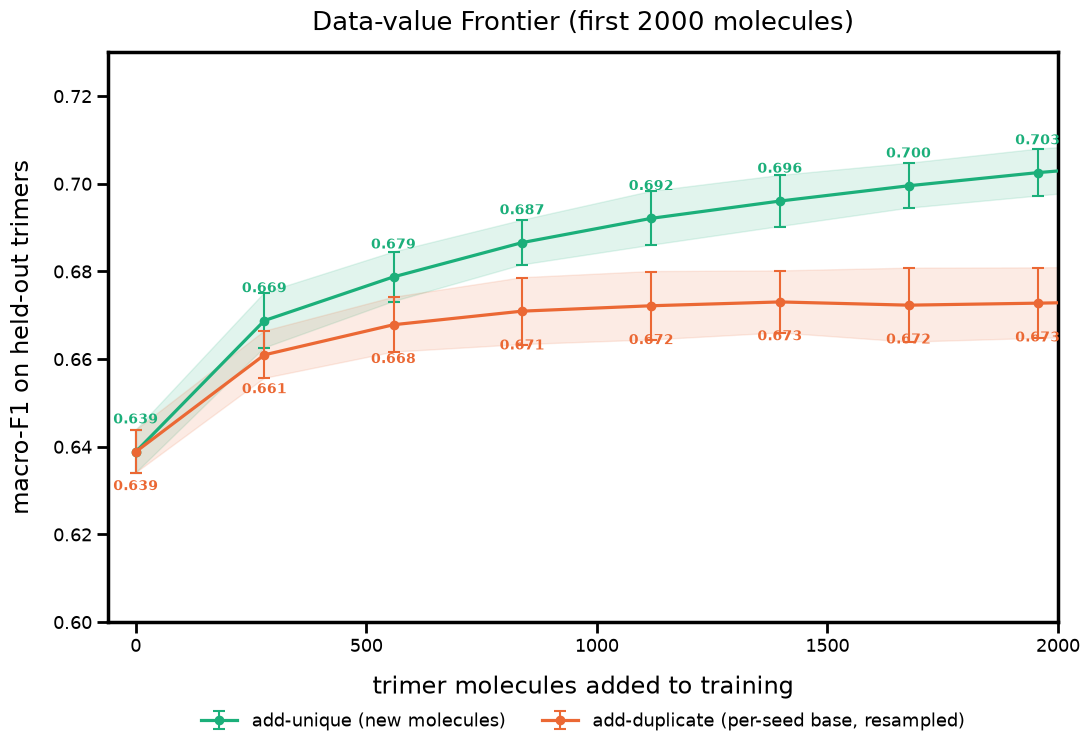

In [11]:
S6F = dict(
    csv  = "frontier_fixed_resampledup_perseedtest_cap10.csv",
    arms = [("unique",    "#1BAF7A", "add-unique (new molecules)"),
            ("duplicate", "#EB6834", "add-duplicate (per-seed base, resampled)")],
    xmax = 2000, xmin = -60, xtick = 500, ymin = 0.60, ymax = 0.73,
    annotate_points = True, shade_ci = True, label_dy = 18,
    xlabel = "trimer molecules added to training", ylabel = "macro-F1 on held-out trimers",
    title  = "Data-value Frontier (first 2000 molecules)",
    title_fontsize = 19, label_fontsize = 17, legend_fontsize = 13, tick_labelsize = 13,
    spine_width = 2.5, figsize = (11, 7.6),
    outfile = "step6_frontier_figC_zoom_cap10.svg", dpi = 600,
)

def plot_frontier(cfg):
    df = results.load_csv("step6", cfg["csv"])
    fig, ax = plt.subplots(figsize=cfg["figsize"])
    for arm, color, label in cfg["arms"]:
        d = df[df["arm"] == arm].groupby("pct").agg(mean=("macro_f1", "mean"), std=("macro_f1", "std"),
                                                    count=("macro_f1", "size"),
                                                    x=("n_molecules_added", "mean")).reset_index()
        ci = 1.96 * d["std"] / np.sqrt(d["count"])          # honest 95% CI over the 10 seeds
        if cfg.get("shade_ci"):
            ax.fill_between(d["x"], d["mean"] - ci, d["mean"] + ci, color=color, alpha=0.13, zorder=1)
        ax.errorbar(d["x"], d["mean"], yerr=ci, marker="o", color=color, lw=2.3, markersize=6,
                    capsize=4, capthick=1.5, elinewidth=1.5, label=label, zorder=3)
        if cfg.get("annotate_points"):
            xm = cfg.get("xmax"); dvis = d[d["x"] <= xm] if xm is not None else d
            up = cfg.get("label_dy", 14); dy = up if arm == cfg["arms"][0][0] else -(up + 2)
            va = "bottom" if dy > 0 else "top"
            for xv, mv in zip(dvis["x"], dvis["mean"]):
                ax.annotate(f"{mv:.3f}", (xv, mv), xytext=(0, dy), textcoords="offset points",
                            ha="center", va=va, fontsize=10, color=color, fontweight="bold")
    ax.set_xlabel(cfg["xlabel"], fontsize=cfg["label_fontsize"], labelpad=14)
    ax.set_ylabel(cfg["ylabel"], fontsize=cfg["label_fontsize"], labelpad=14)
    ax.set_title(cfg["title"], fontsize=cfg["title_fontsize"], pad=16)
    ax.set_ylim(cfg["ymin"], cfg["ymax"])
    if cfg.get("xmax") is not None:
        ax.set_xlim(cfg.get("xmin", -cfg["xmax"] * 0.03), cfg["xmax"])
        ax.xaxis.set_major_locator(MultipleLocator(cfg.get("xtick", 500)))
    for sp in ax.spines.values(): sp.set_linewidth(cfg["spine_width"])
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=cfg["tick_labelsize"])
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False, fontsize=cfg["legend_fontsize"])
    fig.tight_layout()
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("wrote", out)
    return fig

plot_frontier(S6F);

wrote C:\IRSpectra\skong_2026\figures\step6_length_substitution_perconf_cap10.svg | trimer ceiling 0.723


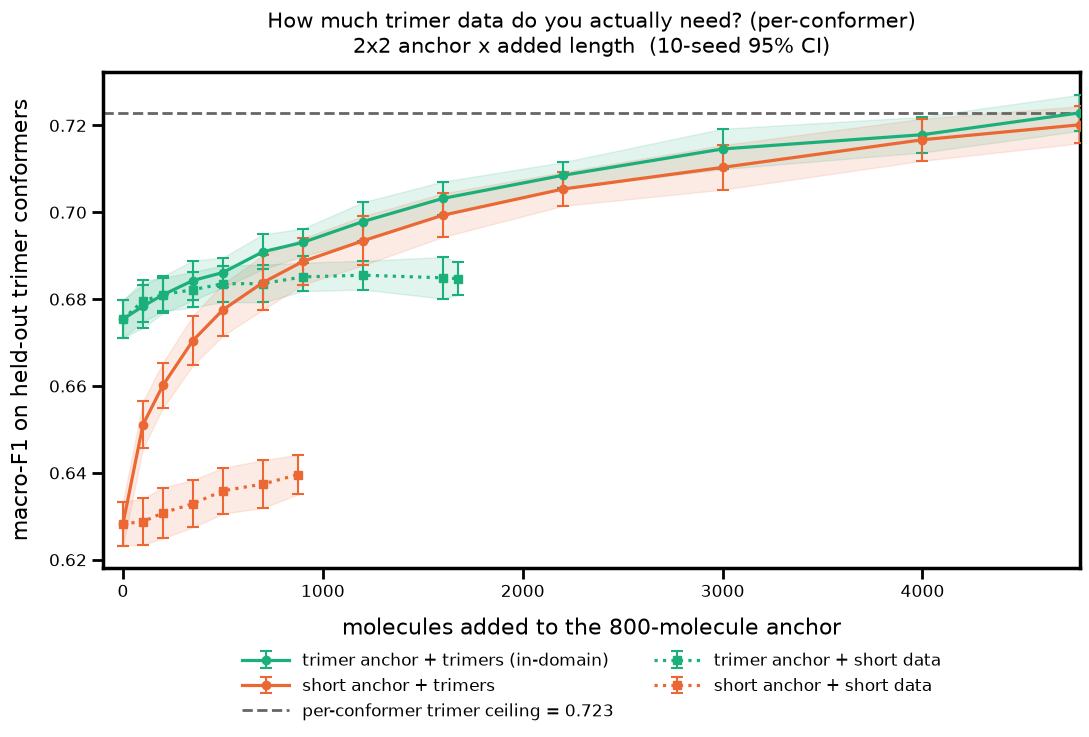

In [12]:
S6L = dict(
    summary_csv = "length_substitution_perconf_cap10_summary.csv",
    meta_json   = "length_substitution_perconf_cap10_meta.json",
    arms = [("A2_trimer_add_trimer", "#1BAF7A", "-", "o", "trimer anchor + trimers (in-domain)"),
            ("A3_trimer_add_short",  "#1BAF7A", ":", "s", "trimer anchor + short data"),
            ("A1_short_add_trimer",  "#EB6834", "-", "o", "short anchor + trimers"),
            ("A4_short_add_short",   "#EB6834", ":", "s", "short anchor + short data")],
    xlabel = "molecules added to the 800-molecule anchor",
    ylabel = "macro-F1 on held-out trimer conformers",
    title  = "How much trimer data do you actually need? (per-conformer)\n2x2 anchor x added length  (10-seed 95% CI)",
    title_fontsize = 15, label_fontsize = 16, legend_fontsize = 12, tick_labelsize = 12,
    spine_width = 2.5, figsize = (11, 7.6),
    outfile = "step6_length_substitution_perconf_cap10.svg", dpi = 600,
)

def plot_length_substitution(cfg):
    s = results.load_csv("step6", cfg["summary_csv"]); s = s[s.metric == "macro_f1"]
    ceil = results.load_json("step6", cfg["meta_json"])["trimer_ceiling_macro_f1_perconf"]
    fig, ax = plt.subplots(figsize=cfg["figsize"])
    for arm, color, ls, mk, label in cfg["arms"]:
        d = s[s.arm == arm].sort_values("n_added")
        ax.fill_between(d["n_added"], d["mean"] - d["ci95"], d["mean"] + d["ci95"], color=color, alpha=0.13, zorder=1)
        ax.errorbar(d["n_added"], d["mean"], yerr=d["ci95"], marker=mk, color=color, ls=ls, lw=2.3,
                    markersize=6, capsize=4, capthick=1.5, elinewidth=1.5, label=label, zorder=3)
    ax.axhline(ceil, ls="--", color="0.4", lw=2, zorder=2, label=f"per-conformer trimer ceiling = {ceil:.3f}")
    ax.set_xlabel(cfg["xlabel"], fontsize=cfg["label_fontsize"], labelpad=12)
    ax.set_ylabel(cfg["ylabel"], fontsize=cfg["label_fontsize"], labelpad=12)
    ax.set_title(cfg["title"], fontsize=cfg["title_fontsize"], pad=14)
    ax.set_xlim(-100, float(s["n_added"].max()))
    for sp in ax.spines.values(): sp.set_linewidth(cfg["spine_width"])
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=cfg["tick_labelsize"])
    handles, labels = ax.get_legend_handles_labels()
    order = ["trimer anchor + trimers (in-domain)", "short anchor + trimers",
             f"per-conformer trimer ceiling = {ceil:.3f}",
             "trimer anchor + short data", "short anchor + short data"]
    hd = dict(zip(labels, handles))
    ax.legend([hd[l] for l in order if l in hd], [l for l in order if l in hd],
              loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False,
              fontsize=cfg["legend_fontsize"], columnspacing=2.4, handlelength=2.8)
    fig.tight_layout()
    out = os.path.join(FIG_DIR, cfg["outfile"]); fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("wrote", out, f"| trimer ceiling {ceil:.3f}")
    return fig

plot_length_substitution(S6L);